In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Set legacy Keras mode BEFORE any TensorFlow/Keras imports
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tf_keras as keras  # Use tf_keras for TFMOT compatibility
from tf_keras import layers
from tf_keras.preprocessing.image import ImageDataGenerator
import tensorflow_model_optimization as tfmot
import tensorflow.lite as tflite

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("CPUs:", tf.config.list_physical_devices("CPU"))


TF version: 2.16.1
GPUs: []
CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [53]:
DATASET_PATH = "D:/waste_project/waste-classification-system-II/resized_dataset"

img_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    color_mode="rgb"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    color_mode="rgb"
)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

Found 8407 files belonging to 9 classes.
Using 6726 files for training.
Found 8407 files belonging to 9 classes.
Using 1681 files for validation.


In [55]:
def ultra_custom_cnn(input_shape=(64, 64, 3), num_classes=4):
    inputs = layers.Input(shape=input_shape)
    x = inputs

    # Block 1
    x = layers.Conv2D(24, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.DepthwiseConv2D(3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.20)(x)

    # Block 2
    x = layers.Conv2D(48, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.DepthwiseConv2D(3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(72, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.DepthwiseConv2D(3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.35)(x)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="ultra_custom_cnn_200k_rgb")


In [60]:
model = ultra_custom_cnn(input_shape=(64, 64, 3), num_classes=num_classes)
model.summary()


Model: "ultra_custom_cnn_200k_rgb"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_13 (InputLayer)       [(None, 64, 64, 3)]       0         
                                                                 
 conv2d_45 (Conv2D)          (None, 64, 64, 24)        648       
                                                                 
 batch_normalization_48 (Ba  (None, 64, 64, 24)        96        
 tchNormalization)                                               
                                                                 
 re_lu_42 (ReLU)             (None, 64, 64, 24)        0         
                                                                 
 depthwise_conv2d_36 (Depth  (None, 64, 64, 24)        216       
 wiseConv2D)                                                     
                                                                 
 batch_normalization_49 (Ba  (None, 64, 6

In [62]:
model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30
)

Epoch 1/30
211/211 [==============================] - 32s 130ms/step - loss: 1.6248 - accuracy: 0.4176 - val_loss: 1.6577 - val_accuracy: 0.4289
Epoch 2/30
211/211 [==============================] - 27s 127ms/step - loss: 1.5981 - accuracy: 0.4332 - val_loss: 1.6806 - val_accuracy: 0.3986
Epoch 3/30
211/211 [==============================] - 27s 127ms/step - loss: 1.5629 - accuracy: 0.4497 - val_loss: 1.5877 - val_accuracy: 0.4420
Epoch 4/30
211/211 [==============================] - 27s 127ms/step - loss: 1.5315 - accuracy: 0.4582 - val_loss: 1.6720 - val_accuracy: 0.4253
Epoch 5/30
211/211 [==============================] - 27s 128ms/step - loss: 1.5068 - accuracy: 0.4719 - val_loss: 1.5861 - val_accuracy: 0.4598
Epoch 6/30
211/211 [==============================] - 27s 130ms/step - loss: 1.4752 - accuracy: 0.4845 - val_loss: 1.7295 - val_accuracy: 0.3831
Epoch 7/30
211/211 [==============================] - 28s 134ms/step - loss: 1.4550 - accuracy: 0.4923 - val_loss: 1.7519 - val_ac

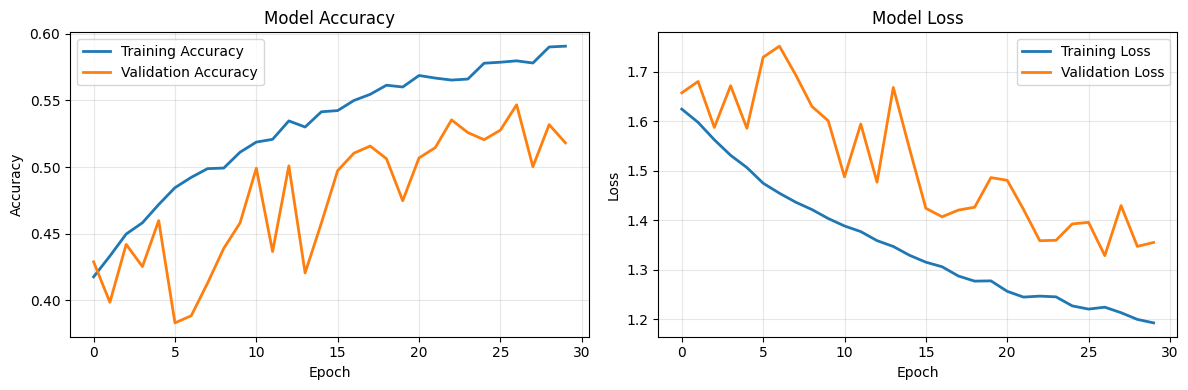

In [63]:
import matplotlib.pyplot as plt

# Plot training history
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
import numpy as np

wrong_images = []
wrong_labels = []

for batch_images, batch_labels in val_ds:
    preds = model.predict(batch_images)
    pred_labels = np.argmax(preds, axis=1)

    for i in range(len(batch_labels)):
        if pred_labels[i] != batch_labels[i]:
            wrong_images.append(batch_images[i])
            wrong_labels.append((batch_labels[i].numpy(), pred_labels[i]))


1/1 [==============================] - 1s 803ms/step


In [44]:
import cv2
import numpy as np

def background_ratio(img):
    # img is 64x64 grayscale
    edges = cv2.Canny((img.numpy()*255).astype(np.uint8), 50, 150)
    return np.sum(edges) / (64*64)

bad_background = []

for batch_images, _ in train_ds:
    for img in batch_images:
        if background_ratio(img) < 0.01:  # almost no edges
            bad_background.append(img)


In [45]:
feature_model = keras.Model(
    inputs=model.input,
    outputs=model.layers[-2].output  # GAP layer
)

features = []
labels = []

for batch_images, batch_labels in train_ds:
    f = feature_model.predict(batch_images)
    features.append(f)
    labels.append(batch_labels.numpy())

features = np.vstack(features)
labels = np.hstack(labels)


1/1 [==============================] - 0s 48ms/step


In [46]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=1.5, min_samples=3).fit(features)
outliers = np.where(db.labels_ == -1)[0]


In [48]:
class_names = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

print("Class counts:\n")
for cls in class_names:
    cls_path = os.path.join(DATASET_PATH, cls)
    count = len([
        f for f in os.listdir(cls_path)
        if os.path.isfile(os.path.join(cls_path, f))
    ])
    print(f"{cls}: {count}")

Class counts:

cardboard: 893
e-waste: 993
glass: 948
metal: 901
organic: 967
paper: 853
plastic: 891
textile: 985
trash: 976


In [59]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)  # Should be (32, 64, 64, 3)
    print("Labels shape:", labels.shape)   # Should be (32,)
print("Model input shape:", model.input_shape)

Images shape: (32, 64, 64, 3)
Labels shape: (32,)
Model input shape: (None, 64, 64, 1)
